In [3]:
from langgraph.graph import START, END, StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
import operator
from dotenv import load_dotenv

/home/kamadahanam/Documents/ALL_WORKS/Programming/LangChain/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
load_dotenv('../.env')

True

In [5]:
model = ChatGoogleGenerativeAI(model = 'gemini-2.5-flash')

In [6]:
essay="""
## Evolution of Civic Sense in India

Civic sense means how people behave in society. It is about keeping places clean, following rules and respecting others. In India, civic sense has changed from old times to now. The change is slow and not very equal in all places.

In ancient India, people believed in religion and duty. They followed *dharma* and listened to kings. Society was simple and villages were small. People knew each other, so they behaved properly most of the time. There were not many big cities, so problems like pollution and traffic was not there much. Civic sense was there but it was mostly because of fear of religion and society.

In medieval time, rulers controlled cities. Big cities started growing. Roads and markets were built. But people followed rules because of punishment. There was not much idea of public responsibility. If ruler was strong, things were fine. If ruler was weak, discipline was less.

During British rule, many new systems came like railways, police and municipalities. Laws were made for sanitation and order. But Indians did not feel connected to these laws because they were under foreign rule. So civic sense did not grow properly. At the same time, freedom fighters talked about discipline and unity, which helped people understand some responsibility.

After independence, India became democratic. Citizens got rights and duties. But population increased very fast. Cities became crowded. Many people throw garbage on roads and do not follow traffic rules. Government made rules but implementation is weak. Corruption also makes people careless. Sometimes people think that one person cannot change anything, so they ignore civic duties.

In recent years, government started campaigns like Swachh Bharat. People are slowly becoming aware. Social media also spreads messages. Still, many problems are there. In villages civic sense may be better in some cases, but in cities it is often poor.

In conclusion, civic sense in India has evolved but not in a strong way. It started from religion and fear, then moved to law and democracy. But real civic sense, which comes from inside a person, is still developing. India needs more awareness and strict rules so that people can behave better in public places.
"""

In [7]:
class evaluation_schema(BaseModel):

    feedback:Annotated[str, Field(...,description="Detailed Feedback of essay")]
    score:Annotated[float, Field(...,description="score out of 10",ge=0,le=10)]
    

In [8]:
structured_model = model.with_structured_output(evaluation_schema)

In [17]:
class UPSC_state(TypedDict):
    essay: str
    clarity_feedback: str
    analysis_feedback: str
    language_feedback: str
    overall_feedback : str
    individual_scores: Annotated[List[float],operator.add]
    avg_score: float

In [10]:
def evaluate_clarity(state:UPSC_state):

    essay=state['essay']
    prompt=f"Evaluate the given essay on the basis of clarity of thought as for a UPSC aspirant \n {essay}"
    output= structured_model.invoke(prompt)

    return {'clarity_feedback':output.feedback, 'individual_scores':[output.score] }

In [11]:
def evaluate_language(state:UPSC_state):

    essay=state['essay']
    prompt=f"Evaluate the given essay on the basis of language used as for a UPSC aspirant \n {essay}"
    output= structured_model.invoke(prompt)

    return {'language_feedback':output.feedback, 'individual_scores':[output.score] }

In [12]:
def evaluate_analysis(state:UPSC_state):

    essay=state['essay']
    prompt=f"Evaluate the given essay on the basis of analysis depth as for a UPSC aspirant \n {essay}"
    output= structured_model.invoke(prompt)
    
    return {'analysis_feedback':output.feedback, 'individual_scores':[output.score] }

In [19]:
def final_feedback(state:UPSC_state):
    analysis=state['analysis_feedback']
    clarity=state['clarity_feedback']
    language=state['language_feedback']
    prompt=f"Summarixe and give an overall feedback on the basis of given feedbacks \n language feedback:{language} \n analysis feedback:{analysis} \n clarity feedback:{clarity}"
    output= model.invoke(prompt)

    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback':output.content,'avg_score':avg_score }

In [20]:
graph = StateGraph(UPSC_state)

graph.add_node("evaluate_clarity",evaluate_clarity)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("final_feedback",final_feedback)

graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_clarity")
graph.add_edge(START,"evaluate_language")

graph.add_edge("evaluate_analysis","final_feedback")
graph.add_edge("evaluate_clarity","final_feedback")
graph.add_edge("evaluate_language","final_feedback")

graph.add_edge ('final_feedback', END)

workflow=graph.compile()


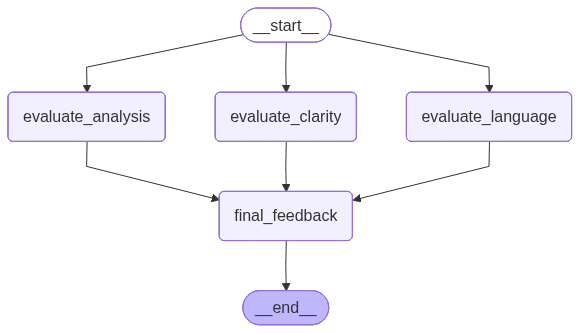

In [21]:
workflow

In [22]:
workflow.invoke({'essay':essay})

{'essay': '\n## Evolution of Civic Sense in India\n\nCivic sense means how people behave in society. It is about keeping places clean, following rules and respecting others. In India, civic sense has changed from old times to now. The change is slow and not very equal in all places.\n\nIn ancient India, people believed in religion and duty. They followed *dharma* and listened to kings. Society was simple and villages were small. People knew each other, so they behaved properly most of the time. There were not many big cities, so problems like pollution and traffic was not there much. Civic sense was there but it was mostly because of fear of religion and society.\n\nIn medieval time, rulers controlled cities. Big cities started growing. Roads and markets were built. But people followed rules because of punishment. There was not much idea of public responsibility. If ruler was strong, things were fine. If ruler was weak, discipline was less.\n\nDuring British rule, many new systems came

In [23]:
essay2="""
# Evolution of Civic Sense in India

Civic sense, in its simplest terms, refers to the responsibility and awareness that citizens display towards society, public property, and fellow human beings. It encompasses respect for laws, maintenance of cleanliness, observance of traffic rules, tolerance in public discourse, and active participation in democratic processes. In a diverse and populous country like India, civic sense is not merely a social virtue but a foundational pillar of democratic governance. The evolution of civic sense in India reflects a journey from community-based ethics to constitutional morality and, today, to participatory citizenship.

## Ancient and Traditional Foundations

The idea of civic responsibility in India is not new. Ancient Indian society was guided by the concept of *dharma*, which emphasized duty towards society. Village communities functioned as largely self-regulating units. Local institutions like *sabhas* and *panchayats* ensured dispute resolution, water management, and maintenance of public resources. Social norms played a major role in regulating behavior, and collective living was central to societal organization.

However, civic sense was largely community-centric and often confined within caste and social hierarchies. The idea of universal and equal civic responsibility was limited.

## Colonial Period: Institutional Framework without Civic Ownership

The British introduced modern civic institutions such as municipalities, codified laws, railways, and urban planning. While these created formal structures of governance, they did not foster civic ownership among the people. The colonial state was perceived as distant and extractive. As a result, public property was often seen as “sarkari” (government-owned) rather than collectively owned.

This psychological detachment weakened the internalization of civic duties. Compliance was driven more by fear of punishment than by moral conviction.

## Post-Independence: Constitutional Morality and Civic Duties

With independence, India adopted a democratic Constitution that granted Fundamental Rights and later incorporated Fundamental Duties. Citizens were expected not only to enjoy rights but also to uphold unity, integrity, and public property.

Dr. B.R. Ambedkar emphasized the importance of constitutional morality — the respect for democratic values and procedures. However, post-independence India faced challenges of poverty, illiteracy, rapid population growth, and developmental pressures. Survival concerns often overshadowed civic responsibilities.

While electoral participation increased and democratic institutions took root, everyday civic behavior — such as cleanliness, traffic discipline, and respect for public spaces — lagged behind constitutional ideals.

## Liberalization and Urban Transformation

The economic reforms of 1991 accelerated urbanization and the growth of a middle class. Expanding cities brought new challenges: congestion, pollution, waste management issues, and strain on infrastructure.

At the same time, civil society activism grew. Public Interest Litigations, environmental movements, and resident welfare associations became instruments of civic assertion. Citizens began demanding accountability from the state, marking a shift from passive subjects to active stakeholders.

However, civic sense remained uneven — often stronger in private spaces and weaker in public domains.

## Contemporary Phase: Behavioral Change and Digital Citizenship

Recent decades have witnessed focused campaigns aimed at improving civic behavior, particularly in sanitation, environmental protection, and public participation. Civic awareness has expanded through media, social platforms, and educational initiatives.

Digital governance has empowered citizens to report grievances and demand transparency. Yet, new challenges have emerged — misinformation, online hate speech, and declining civility in public discourse. Civic sense now extends beyond physical spaces into digital spaces.

## Persistent Challenges

Despite progress, India continues to grapple with:

* The “tragedy of commons” mindset toward public property
* Weak enforcement of civic regulations
* Gaps in value-based education
* Socio-economic inequalities affecting participation
* Politicization of civic issues

Civic sense cannot be legislated into existence; it must be cultivated through socialization and example.

## Way Forward

1. Strengthening civic education at school and university levels.
2. Promoting community participation in local governance.
3. Ensuring consistent enforcement of civic laws.
4. Encouraging ethical leadership and public role models.
5. Integrating civic responsibility into digital literacy programs.

Ultimately, civic sense must move from compulsion to conviction.

## Conclusion

The evolution of civic sense in India mirrors the country’s democratic journey — from community-bound ethics to constitutional aspirations and emerging participatory citizenship. While institutional frameworks are strong, behavioral transformation remains a work in progress.

For India to realize its constitutional vision of justice, liberty, equality, and fraternity, civic sense must become an intrinsic value rather than an imposed obligation. In a democracy, the quality of governance ultimately reflects the quality of citizenship.

"""

In [24]:
workflow.invoke({'essay':essay2})

{'essay': '\n# Evolution of Civic Sense in India\n\nCivic sense, in its simplest terms, refers to the responsibility and awareness that citizens display towards society, public property, and fellow human beings. It encompasses respect for laws, maintenance of cleanliness, observance of traffic rules, tolerance in public discourse, and active participation in democratic processes. In a diverse and populous country like India, civic sense is not merely a social virtue but a foundational pillar of democratic governance. The evolution of civic sense in India reflects a journey from community-based ethics to constitutional morality and, today, to participatory citizenship.\n\n## Ancient and Traditional Foundations\n\nThe idea of civic responsibility in India is not new. Ancient Indian society was guided by the concept of *dharma*, which emphasized duty towards society. Village communities functioned as largely self-regulating units. Local institutions like *sabhas* and *panchayats* ensured 